### NLP From Scratch: Classifying Names with a Character-Level RNN

**************************************************************
**Author**: `Sean Robertson <https://github.com/spro/practical-pytorch>`

#### Print your name

In [1]:
## Your code here 
print("Exercise by: Heidi Putkuri")

Exercise by: Heidi Putkuri


We will be building and training a basic character-level RNN to classify
words. This tutorial, along with the following two, show how to do
preprocess data for NLP modeling "from scratch", in particular not using
many of the convenience functions of `torchtext`, so you can see how
preprocessing for NLP modeling works at a low level.

A character-level RNN reads words as a series of characters -
outputting a prediction and "hidden state" at each step, feeding its
previous hidden state into each next step. We take the final prediction
to be the output, i.e. which class the word belongs to.

Specifically, we'll train on a few thousand surnames from 18 languages
of origin, and predict which language a name is from based on the
spelling:

::

    $ python predict.py Hinton
    (-0.47) Scottish
    (-1.52) English
    (-3.57) Irish

    $ python predict.py Schmidhuber
    (-0.19) German
    (-2.48) Czech
    (-2.68) Dutch


**Recommended Reading:**

I assume you have at least installed PyTorch, know Python, and
understand Tensors:

-  https://pytorch.org/ For installation instructions
-  :doc:`/beginner/deep_learning_60min_blitz` to get started with PyTorch in general
-  :doc:`/beginner/pytorch_with_examples` for a wide and deep overview
-  :doc:`/beginner/former_torchies_tutorial` if you are former Lua Torch user

It would also be useful to know about RNNs and how they work:

-  `The Unreasonable Effectiveness of Recurrent Neural
   Networks <https://karpathy.github.io/2015/05/21/rnn-effectiveness/>`__
   shows a bunch of real life examples
-  `Understanding LSTM
   Networks <https://colah.github.io/posts/2015-08-Understanding-LSTMs/>`__
   is about LSTMs specifically but also informative about RNNs in
   general

Preparing the Data
==================

.. Note::
   Download the data from
   `here <https://download.pytorch.org/tutorial/data.zip>`_
   and extract it to the current directory.

Included in the ``data/names`` directory are 18 text files named as
"[Language].txt". Each file contains a bunch of names, one name per
line, mostly romanized (but we still need to convert from Unicode to
ASCII).

We'll end up with a dictionary of lists of names per language,
``{language: [names ...]}``. The generic variables "category" and "line"
(for language and name in our case) are used for later extensibility.



In [2]:
%matplotlib inline

In [3]:
from __future__ import unicode_literals, print_function, division
from io import open
import glob
import os

def findFiles(path): return glob.glob(path)

print(findFiles('../data/names/*.txt'))

import unicodedata
import string

all_letters = string.ascii_letters + " .,;'"
n_letters = len(all_letters)

# Turn a Unicode string to plain ASCII, thanks to https://stackoverflow.com/a/518232/2809427
def unicodeToAscii(s):
    return ''.join(
        c for c in unicodedata.normalize('NFD', s)
        if unicodedata.category(c) != 'Mn'
        and c in all_letters
    )

print(unicodeToAscii('Ślusàrski'))

# Build the category_lines dictionary, a list of names per language
category_lines = {}
all_categories = []

# Read a file and split into lines
def readLines(filename):
    lines = open(filename, encoding='utf-8').read().strip().split('\n')
    return [unicodeToAscii(line) for line in lines] # return list of names in ascii

for filename in findFiles('../data/names/*.txt'):
    category = os.path.splitext(os.path.basename(filename))[0]
    all_categories.append(category)
    lines = readLines(filename)
    category_lines[category] = lines

n_categories = len(all_categories)

['../data/names/Czech.txt', '../data/names/German.txt', '../data/names/Arabic.txt', '../data/names/Japanese.txt', '../data/names/Chinese.txt', '../data/names/Vietnamese.txt', '../data/names/Russian.txt', '../data/names/French.txt', '../data/names/Irish.txt', '../data/names/English.txt', '../data/names/Spanish.txt', '../data/names/Greek.txt', '../data/names/Italian.txt', '../data/names/Portuguese.txt', '../data/names/Scottish.txt', '../data/names/Dutch.txt', '../data/names/Korean.txt', '../data/names/Polish.txt']
Slusarski


Now we have ``category_lines``, a dictionary mapping each category
(language) to a list of lines (names). We also kept track of
``all_categories`` (just a list of languages) and ``n_categories`` for
later reference.




In [4]:
print(category_lines['Italian'][:5])

['Abandonato', 'Abatangelo', 'Abatantuono', 'Abate', 'Abategiovanni']


Turning Names into Tensors
--------------------------

Now that we have all the names organized, we need to turn them into
Tensors to make any use of them.

To represent a single letter, we use a "one-hot vector" of size
``<1 x n_letters>``. A one-hot vector is filled with 0s except for a 1
at index of the current letter, e.g. ``"b" = <0 1 0 0 0 ...>``.

To make a word we join a bunch of those into a 2D matrix
``<line_length x 1 x n_letters>``.

That extra 1 dimension is because PyTorch assumes everything is in
batches - we're just using a batch size of 1 here.




In [5]:
import torch
import time
import math
# Find letter index from all_letters, e.g. "a" = 0
def letterToIndex(letter):
    return all_letters.find(letter)

# Just for demonstration, turn a letter into a <1 x n_letters> Tensor
def letterToTensor(letter):
    tensor = torch.zeros(1, n_letters)
    tensor[0][letterToIndex(letter)] = 1
    return tensor

# Turn a line into a <line_length x 1 x n_letters>,
# or an array of one-hot letter vectors
def lineToTensor(line):
    tensor = torch.zeros(len(line), 1, n_letters)
    for li, letter in enumerate(line):
        tensor[li][0][letterToIndex(letter)] = 1
    return tensor

print(letterToTensor('J'))

print(lineToTensor('Jones').size())

tensor([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0.]])
torch.Size([5, 1, 57])


Creating the Network
====================

Before autograd, creating a recurrent neural network in Torch involved
cloning the parameters of a layer over several timesteps. The layers
held hidden state and gradients which are now entirely handled by the
graph itself. This means you can implement a RNN in a very "pure" way,
as regular feed-forward layers.

This RNN module (mostly copied from `the PyTorch for Torch users
tutorial <https://pytorch.org/tutorials/beginner/former_torchies/
nn_tutorial.html#example-2-recurrent-net>`__)
is just 2 linear layers which operate on an input and hidden state, with
a LogSoftmax layer after the output.

.. figure:: https://i.imgur.com/Z2xbySO.png
   :alt:





In [6]:
import torch.nn as nn

class RNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(RNN, self).__init__()

        self.hidden_size = hidden_size # hidden layer initialized

        self.i2h = nn.Linear(input_size + hidden_size, hidden_size) # input to hidden layer
        self.i2o = nn.Linear(input_size + hidden_size, output_size) # input to output layer
        self.softmax = nn.LogSoftmax(dim=1) # softmax function

    def forward(self, input, hidden):
        combined = torch.cat((input, hidden), 1) # concatenate input and hidden layer
        hidden = self.i2h(combined) # calculate hidden layer, so calculates the next hidden layer
        output = self.i2o(combined) # calculate output layer
        output = self.softmax(output)
        return output, hidden

    def initHidden(self):
        return torch.zeros(1, self.hidden_size)

n_hidden = 128
rnn = RNN(n_letters, n_hidden, n_categories)

To run a step of this network we need to pass an input (in our case, the
Tensor for the current letter) and a previous hidden state (which we
initialize as zeros at first). We'll get back the output (probability of
each language) and a next hidden state (which we keep for the next
step).




In [7]:
input = letterToTensor('A')
hidden =torch.zeros(1, n_hidden)

output, next_hidden = rnn(input, hidden)

For the sake of efficiency we don't want to be creating a new Tensor for
every step, so we will use ``lineToTensor`` instead of
``letterToTensor`` and use slices. This could be further optimized by
pre-computing batches of Tensors.




In [8]:
input = lineToTensor('Albert')
hidden = torch.zeros(1, n_hidden)

output, next_hidden = rnn(input[0], hidden)
print(output)

tensor([[-2.8005, -2.8506, -2.9460, -2.9050, -2.8457, -2.8373, -2.8607, -2.9383,
         -2.9212, -2.8433, -2.8483, -2.8339, -2.9126, -2.9098, -3.0160, -2.9736,
         -2.8878, -2.9227]], grad_fn=<LogSoftmaxBackward0>)


As you can see the output is a ``<1 x n_categories>`` Tensor, where
every item is the likelihood of that category (higher is more likely).




Training
========
Preparing for Training
----------------------

Before going into training we should make a few helper functions. The
first is to interpret the output of the network, which we know to be a
likelihood of each category. We can use ``Tensor.topk`` to get the index
of the greatest value:




In [9]:
def categoryFromOutput(output):
    top_n, top_i = output.topk(1)
    category_i = top_i[0].item()
    return all_categories[category_i], category_i # returns the category (language) and the index of the category

print(categoryFromOutput(output))

('Czech', 0)


We will also want a quick way to get a training example (a name and its
language):




In [10]:
import random

def randomChoice(l):
    return l[random.randint(0, len(l) - 1)] # choose random element from the list

def randomTrainingExample():
    category = randomChoice(all_categories) # choose random category
    line = randomChoice(category_lines[category]) # choose random name from the category
    category_tensor = torch.tensor([all_categories.index(category)], dtype=torch.long) # convert the category to tensor
    line_tensor = lineToTensor(line) # convert the name to tensor
    return category, line, category_tensor, line_tensor # return the category, name, category tensor and name tensor

for i in range(10):
    category, line, category_tensor, line_tensor = randomTrainingExample()
    print('category =', category, '/ line =', line)

category = English / line = Sellars
category = Italian / line = Calabrese
category = Greek / line = Konstantatos
category = Dutch / line = Altena
category = Dutch / line = Rooiakker
category = Vietnamese / line = Do
category = Greek / line = Close
category = French / line = Dufort
category = Scottish / line = Maclean
category = English / line = Halford


Training the Network
--------------------

Now all it takes to train this network is show it a bunch of examples,
have it make guesses, and tell it if it's wrong.

For the loss function ``nn.NLLLoss`` is appropriate, since the last
layer of the RNN is ``nn.LogSoftmax``.




In [11]:
criterion = nn.NLLLoss()

Each loop of training will:

-  Create input and target tensors
-  Create a zeroed initial hidden state
-  Read each letter in and

   -  Keep hidden state for next letter

-  Compare final output to target
-  Back-propagate
-  Return the output and loss




In [12]:
learning_rate = 0.005 # If you set this too high, it might explode. If too low, it might not learn

def train(category_tensor, line_tensor):
    hidden = rnn.initHidden() # initialize hidden layer

    rnn.zero_grad() # zero the gradients

    for i in range(line_tensor.size()[0]):
        output, hidden = rnn(line_tensor[i], hidden)

    loss = criterion(output, category_tensor) # calculate loss
    loss.backward() # backpropagation update the weights

    # Add parameters' gradients to their values, multiplied by learning rate
    for p in rnn.parameters():
        p.data.add_(p.grad.data, alpha=-learning_rate)

    return output, loss.item() # return the output and the loss, loss.item() returns the scalar value held in the loss.

Now we just have to run that with a bunch of examples. Since the
``train`` function returns both the output and loss we can print its
guesses and also keep track of loss for plotting. Since there are 1000s
of examples we print only every ``print_every`` examples, and take an
average of the loss.




In [13]:


n_iters = 100000
print_every = 5000
plot_every = 1000

# Keep track of losses for plotting
current_loss = 0
all_losses = []
def timeSince(since):
    now = time.time()
    s = now - since
    m = math.floor(s / 60)
    s -= m * 60
    return '%dm %ds' % (m, s)

start = time.time()

for iter in range(1, n_iters + 1):
    category, line, category_tensor, line_tensor = randomTrainingExample() # get random training example of y and x values
    output, loss = train(category_tensor, line_tensor) # train the model using the training example x_train and y_train
    current_loss += loss 

    # Print iter number, loss, name and guess
    if iter % print_every == 0:
        guess, guess_i = categoryFromOutput(output)
        correct = '✓' if guess == category else '✗ (%s)' % category
        print('%d %d%% (%s) %.4f %s / %s %s' % (iter, iter / n_iters * 100, timeSince(start), loss, line, guess, correct))

    # Add current loss avg to list of losses
    if iter % plot_every == 0:
        all_losses.append(current_loss / plot_every)
        current_loss = 0

5000 5% (0m 2s) 2.1832 Adamczyk / Russian ✗ (Polish)
10000 10% (0m 5s) 1.8375 Bach / Vietnamese ✓
15000 15% (0m 7s) 1.6529 Fonseca / Portuguese ✓
20000 20% (0m 9s) 0.6583 Patselas / Greek ✓
25000 25% (0m 12s) 4.1951 Botros / Greek ✗ (Arabic)
30000 30% (0m 14s) 1.1621 Chung / Korean ✗ (Vietnamese)
35000 35% (0m 16s) 2.6513 Melo / Spanish ✗ (Portuguese)
40000 40% (0m 19s) 1.8110 Haik / Korean ✗ (Arabic)
45000 45% (0m 21s) 0.4026 Kasprzak / Polish ✓
50000 50% (0m 23s) 1.7216 Marek / Polish ✓
55000 55% (0m 26s) 2.0906 Liang / Vietnamese ✗ (Chinese)
60000 60% (0m 28s) 0.6294 Seo / Korean ✓
65000 65% (0m 30s) 1.4704 Langbroek / Czech ✗ (Dutch)
70000 70% (0m 33s) 1.1229 Ortega / Spanish ✓
75000 75% (0m 35s) 1.0847 Kwak / Korean ✓
80000 80% (0m 37s) 0.6818 Tassioglou / Greek ✓
85000 85% (0m 40s) 0.7666 Murray / Scottish ✓
90000 90% (0m 42s) 0.4817 Bonnaire / French ✓
95000 95% (0m 44s) 0.2796 Xin / Chinese ✓
100000 100% (0m 47s) 1.2782 Mclain / Irish ✓


Plotting the Results
--------------------

Plotting the historical loss from ``all_losses`` shows the network
learning:




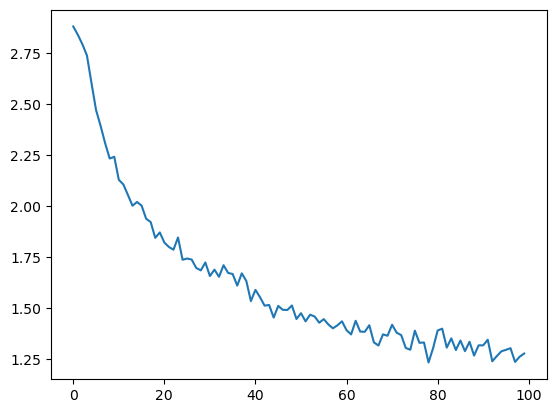

In [14]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.figure()
plt.plot(all_losses)

Evaluating the Results
======================

To see how well the network performs on different categories, we will
create a confusion matrix, indicating for every actual language (rows)
which language the network guesses (columns). To calculate the confusion
matrix a bunch of samples are run through the network with
``evaluate()``, which is the same as ``train()`` minus the backprop.




/var/folders/4d/36mhsq510hsgz5kb3bc056vc0000gn/T/ipykernel_16019/2681064227.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + all_categories, rotation=90)
/var/folders/4d/36mhsq510hsgz5kb3bc056vc0000gn/T/ipykernel_16019/2681064227.py:45: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + all_categories)


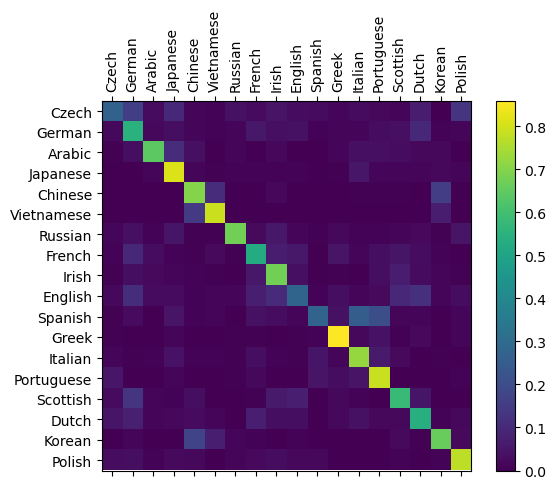

In [15]:
# Keep track of correct guesses in a confusion matrix
confusion = torch.zeros(n_categories, n_categories) # initialize confusion matrix with zeros
n_confusion = 10000 # number of examples to evaluate

# Just return an output given a line
def evaluate(line_tensor):
    """Function to evaluate the model using the test data
    Args:
        line_tensor (tensor): tensor containing the names
    Returns:
        output: output of the model
    """
    hidden = rnn.initHidden() # initialize hidden layer

    for i in range(line_tensor.size()[0]): # go through the line tensor
        output, hidden = rnn(line_tensor[i], hidden) # calculate output and hidden layer

    return output

# Go through a bunch of examples and record which are correctly guessed
for i in range(n_confusion):
    category, line, category_tensor, line_tensor = randomTrainingExample() # get random training example
    # category is the actual category of the name, line is the name
    # category_tensor is the tensor of the category, line_tensor is the tensor of the name
    output = evaluate(line_tensor) # evaluate the model using the training example x_train, which is the line_tensor containing the names
    guess, guess_i = categoryFromOutput(output)  
    # guess = the name of the category that the RNN model predicts
    # guess_i = the index of the category that the RNN model predicts
    category_i = all_categories.index(category)
    confusion[category_i][guess_i] += 1 # add 1 to the confusion matrix at the actual category and the predicted category


# Normalize by dividing every row by its sum
for i in range(n_categories):
    confusion[i] = confusion[i] / confusion[i].sum()
# proportion of predictions for that actual category that were predicted as each possible category
# Set up plot
fig = plt.figure()
ax = fig.add_subplot(111)
cax = ax.matshow(confusion.numpy())
fig.colorbar(cax)

# Set up axes
ax.set_xticklabels([''] + all_categories, rotation=90)
ax.set_yticklabels([''] + all_categories)

# Force label at every tick
ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax.yaxis.set_major_locator(ticker.MultipleLocator(1))

# sphinx_gallery_thumbnail_number = 2
plt.show()

You can pick out bright spots off the main axis that show which
languages it guesses incorrectly, e.g. Chinese for Korean, and Spanish
for Italian. It seems to do very well with Greek, and very poorly with
English (perhaps because of overlap with other languages).




Running on User Input
---------------------




In [16]:
def predict(input_line, n_predictions=3):
    print('\n> %s' % input_line) # print the input name
    with torch.no_grad():
        output = evaluate(lineToTensor(input_line)) # evaluate the model using the input name

        # Get top N categories
        topv, topi = output.topk(n_predictions, 1, True) # get the top n_predictions categories
        predictions = []

        for i in range(n_predictions):
            value = topv[0][i].item()
            category_index = topi[0][i].item()
            print('(%.2f) %s' % (value, all_categories[category_index]))
            predictions.append([value, all_categories[category_index]])

predict('Dovesky')
predict('Jackson')
predict('Satoshi')


> Dovesky
(-0.75) Czech
(-0.98) Russian
(-2.75) Polish

> Jackson
(-0.87) Scottish
(-1.19) English
(-2.24) Russian

> Satoshi
(-1.18) Italian
(-1.39) Japanese
(-1.62) Polish


# Background information
# ----------------------

The final versions of the scripts `in the Practical PyTorch
repo <https://github.com/spro/practical-pytorch/tree/master/char-rnn-classification>`__
split the above code into a few files:

-  ``data.py`` (loads files)
-  ``model.py`` (defines the RNN)
-  ``train.py`` (runs training)
-  ``predict.py`` (runs ``predict()`` with command line arguments)
-  ``server.py`` (serve prediction as a JSON API with bottle.py)

Run ``train.py`` to train and save the network.

Run ``predict.py`` with a name to view predictions:

::

    $ python predict.py Hazaki
    (-0.42) Japanese
    (-1.39) Polish
    (-3.51) Czech

Run ``server.py`` and visit http://localhost:5533/Yourname to get JSON
output of predictions.


# Exercises
# ---------

-  Try with a different dataset of line -> category, for example:

   -  Any word -> language
   -  First name -> gender
   -  Character name -> writer
   -  Page title -> blog or subreddit

-  Get better results with a bigger and/or better shaped network

   -  Add more linear layers
   -  Try the ``nn.LSTM`` and ``nn.GRU`` layers
   -  Combine multiple of these RNNs as a higher level network


In [ ]:
#Tutustu nimiä luokittelevaan RNN -verkkoon ja lisää siihen suomalaisten sukunimien tunnistus
#Lisätty tiedosto Finnish.txt kansioon /data/names jossa vain suomalaisia sukunimiä joista yli 1000kpl
#!mv ../data/Finnish.txt ../data/names/

all_letters = string.ascii_letters + " .,;'"
n_letters = len(all_letters)

# Turn a Unicode string to plain ASCII, thanks to https://stackoverflow.com/a/518232/2809427
def unicodeToAscii(s):
    return ''.join(
        c for c in unicodedata.normalize('NFD', s)
        if unicodedata.category(c) != 'Mn'
        and c in all_letters
    )

print(unicodeToAscii('Ślusàrski'))

# Build the category_lines dictionary, a list of names per language
category_lines = {}
all_categories = []

# Read a file and split into lines
def readLines(filename):
    lines = open(filename, encoding='utf-8').read().strip().split('\n')
    return [unicodeToAscii(line) for line in lines] # return list of names in ascii

for filename in findFiles('../data/names/*.txt'):
    category = os.path.splitext(os.path.basename(filename))[0]
    all_categories.append(category)
    lines = readLines(filename)
    category_lines[category] = lines

n_categories = len(all_categories)

Slusarski


In [18]:
category_lines['Finnish'][:5]

['Korhonen', 'Virtanen', 'Makinen', 'Nieminen', 'Makela']

In [19]:
#3. Nollaa verkko alustamalla se uudestaan ja kouluta se 100 000 iteraation loopilla.
n_hidden = 128
rnn = RNN(n_letters, n_hidden, n_categories)

In [20]:

n_iters = 100000
print_every = 5000
plot_every = 1000

current_loss = 0
all_losses = []
correct_predictions = 0  # Track total correct predictions
total_predictions = 0  # Track total predictions
start = time.time()


for iter in range(1, n_iters + 1):
    category, line, category_tensor, line_tensor = randomTrainingExample()  # Get training example
    output, loss = train(category_tensor, line_tensor)  # Train model

    current_loss += loss  # Accumulate loss
    total_predictions += 1  # Keep track of total samples

    # Get the predicted category and check correctness
    guess, guess_i = categoryFromOutput(output)
    if guess == category:
        correct_predictions += 1  # Cumulative count of correct predictions

    # Print progress every `print_every` iterations
    if iter % print_every == 0:
        avg_loss = current_loss / print_every  # Average loss over last interval
        overall_accuracy = correct_predictions / total_predictions  # Cumulative accuracy

        print(f'{iter} {iter / n_iters * 100:.0f}% ({timeSince(start)}) Loss: {avg_loss:.4f} Accuracy: {overall_accuracy:.4f}')

        all_losses.append(avg_loss)
        current_loss = 0


5000 5% (0m 2s) Loss: 2.7861 Accuracy: 0.2020
10000 10% (0m 4s) Loss: 2.3756 Accuracy: 0.2466
15000 15% (0m 7s) Loss: 2.1163 Accuracy: 0.2829
20000 20% (0m 9s) Loss: 1.9955 Accuracy: 0.3105
25000 25% (0m 12s) Loss: 1.8468 Accuracy: 0.3360
30000 30% (0m 14s) Loss: 1.7390 Accuracy: 0.3579
35000 35% (0m 16s) Loss: 1.6593 Accuracy: 0.3781
40000 40% (0m 19s) Loss: 1.6266 Accuracy: 0.3931
45000 45% (0m 21s) Loss: 1.6134 Accuracy: 0.4064
50000 50% (0m 23s) Loss: 1.5622 Accuracy: 0.4179
55000 55% (0m 26s) Loss: 1.5314 Accuracy: 0.4287
60000 60% (0m 28s) Loss: 1.4931 Accuracy: 0.4380
65000 65% (0m 30s) Loss: 1.4682 Accuracy: 0.4465
70000 70% (0m 33s) Loss: 1.4379 Accuracy: 0.4544
75000 75% (0m 35s) Loss: 1.3952 Accuracy: 0.4625
80000 80% (0m 38s) Loss: 1.3959 Accuracy: 0.4693
85000 85% (0m 40s) Loss: 1.3759 Accuracy: 0.4756
90000 90% (0m 42s) Loss: 1.3326 Accuracy: 0.4821
95000 95% (0m 45s) Loss: 1.3700 Accuracy: 0.4867
100000 100% (0m 47s) Loss: 1.3243 Accuracy: 0.4918


/var/folders/4d/36mhsq510hsgz5kb3bc056vc0000gn/T/ipykernel_16019/635001480.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + all_categories, rotation=90)
/var/folders/4d/36mhsq510hsgz5kb3bc056vc0000gn/T/ipykernel_16019/635001480.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + all_categories)


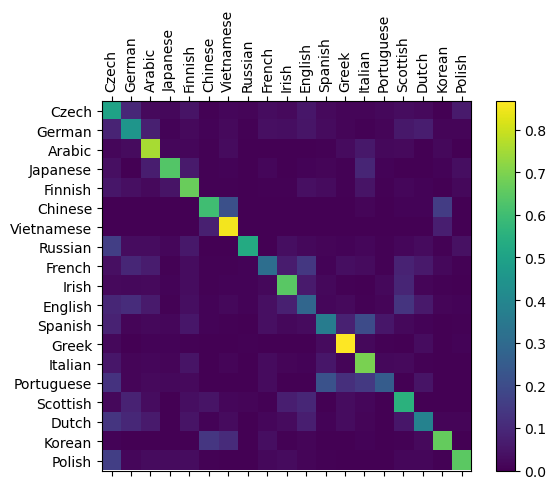

In [ ]:
confusion = torch.zeros(n_categories, n_categories) # initialize confusion matrix with zeros
n_confusion = 10000 # number of examples to evaluate

# Go through a bunch of examples and record which are correctly guessed
for i in range(n_confusion):
    category, line, category_tensor, line_tensor = randomTrainingExample() # get random training example
    # category is the actual category of the name, line is the name
    # category_tensor is the tensor of the category, line_tensor is the tensor of the name
    output = evaluate(line_tensor) # evaluate the model using the training example x_train, which is the line_tensor containing the names
    guess, guess_i = categoryFromOutput(output)  
    # guess = the name of the category that the RNN model predicts
    # guess_i = the index of the category that the RNN model predicts
    category_i = all_categories.index(category)
    confusion[category_i][guess_i] += 1 # add 1 to the confusion matrix at the actual category and the predicted category

# Normalize by dividing every row by its sum --> proportion of predictions for that actual category that were predicted as each possible category
for i in range(n_categories):
    confusion[i] = confusion[i] / confusion[i].sum()
# Set up plot
fig = plt.figure()
ax = fig.add_subplot(111)
cax = ax.matshow(confusion.numpy())
fig.colorbar(cax)

# Set up axes
ax.set_xticklabels([''] + all_categories, rotation=90)
ax.set_yticklabels([''] + all_categories)

# Force label at every tick
ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax.yaxis.set_major_locator(ticker.MultipleLocator(1))

# sphinx_gallery_thumbnail_number = 2
plt.show()

In [ ]:
for i in range(n_categories):
    print(all_categories[i], confusion[i][i].item()) # print the accuracy of each category from the confusion matrix diagonal



Czech 0.5
German 0.45136186480522156
Arabic 0.7527881264686584
Japanese 0.634765625
Finnish 0.667870044708252
Chinese 0.6000000238418579
Vietnamese 0.8517823815345764
Russian 0.5290806889533997
French 0.3139534890651703
Irish 0.6468330025672913
English 0.285451203584671
Spanish 0.3646833002567291
Greek 0.8674464225769043
Italian 0.6945996284484863
Portuguese 0.25183823704719543
Scottish 0.5533088445663452
Dutch 0.3835051655769348
Korean 0.6608863472938538
Polish 0.6496945023536682


## Kuinka monta % suomalaisista nimistä verkko osaa ennustaa oikein suomalaisiksi?

In [ ]:
i = all_categories.index('Finnish')
print(all_categories[i], confusion[i][i].item()*100)

Finnish 66.7870044708252


# Can the model predic the language of your name?


In [25]:
def predict(input_line, n_predictions=3):
    print('\n> %s' % input_line) # print the input name
    with torch.no_grad():
        output = evaluate(lineToTensor(input_line)) # evaluate the model using the input name

        # Get top N categories
        topv, topi = output.topk(n_predictions, 1, True) # get the top n_predictions categories
        predictions = []

        for i in range(n_predictions):
            value = topv[0][i].item()
            category_index = topi[0][i].item()
            print('(%.2f) %s' % (value, all_categories[category_index]))
            predictions.append([value, all_categories[category_index]])

In [29]:
predict('Putkuri')


> Putkuri
(-1.68) Finnish
(-1.81) Japanese
(-1.92) Italian


(-1.68) Finnish = probability of 18,6 <br>
(-1.81) Japanese = probability of 16,4 <br>
(-1.92) Italian = probability of 14,7

# Reflection

1. How accurate neural network is?
2. How many % of Finnish names network predicts correctly as Finnish? 
3. Try your sur name. What neural netwoprk predicts?
4. What you could do to improve neural network performance? 

1. The networks accuracy is around Accuracy: 0.4918 = ~49% which is not very good.
2. The network predicts around 63% of Finnish names correctly as Finnish.
3. The network predicts my surname (Putkuri) as Finnish with a probability of 18.6%.
4. To improve the performance of the network, we could add more data to the training set, or we could try to use a different model, such as an LSTM or GRU. We could also try to add more layers to the network, or we could try to use a different optimizer.



In [ ]:
#!mv ../data/names/Finnish.txt ../data to retraint the model without the Finnish names